In [1]:
%load_ext autoreload
%autoreload 2
import torch
from training_functions import train, evaluate_mae_mse
from mcnn import MCNN
import torch.nn as nn
import torch.optim as optim
from dataloader_mcnn import CrowdDataset
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, ConcatDataset
import glob
import os
import numpy as np
import random
import time
import pandas as pd
SEED = 42

In [2]:
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)

In [ ]:
main_folders = [r"/kaggle/input/datasets/wiktorwoniak/shanghaitech-part-a/ShanghaiTech_part_A", 
                r"/kaggle/input/datasets/wiktorwoniak/shanghaitech-part-b/ShanghaiTech_part_B"]

train_datasets = []
val_datasets = []

for folder in main_folders:
    train_img_root = os.path.join(folder, "train", "images")
    train_map_root = os.path.join(folder, "train", "maps")
    print(folder)
    if os.path.exists(train_img_root) and os.path.exists(train_map_root):
        print('ok')
        train_datasets.append(CrowdDataset(train_img_root, train_map_root, gt_downsample=4, resize=False))
    
    val_img_root = os.path.join(folder, "test", "images")
    val_map_root = os.path.join(folder, "test", "maps")
    
    if os.path.exists(val_img_root) and os.path.exists(val_map_root):
        val_datasets.append(CrowdDataset(val_img_root, val_map_root, gt_downsample=4, resize=False))

train_dataset = ConcatDataset(train_datasets)
val_dataset = ConcatDataset(val_datasets)

train_loader = DataLoader(train_dataset, batch_size=1, shuffle=True, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=1, shuffle=False,pin_memory=True)

ok
ok
ok
ok
ok


In [ ]:
set_seed(SEED)
model_dir = "/kaggle/working/MSC-thesis/output/models/mcnn"
history_dir = "/kaggle/working/MSC-thesis/output/history/mcnn"

os.makedirs(model_dir, exist_ok=True)
os.makedirs(history_dir, exist_ok=True)

model_path = model_dir + "/mcnn.pth"
history_path = history_dir + "/mcnn.pkl"

device = "cuda" if torch.cuda.is_available() else "cpu"
model = MCNN()
model.load_state_dict(torch.load('/kaggle/working/MSC-thesis/output/models/mcnn/mcnn.pth'))
model.eval()
model = model.to(device)
epochs = 100
tolerance = 20

criterion = nn.MSELoss().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)


start_time = time.time()
history = train(epochs, model, train_loader, val_loader, optimizer, criterion, device,model_path, tolerance = tolerance)
end_time = time.time()
print(f"total time: {end_time - start_time}\n")

e:\OneDrive\Pulpit\MSC-thesis\.venv\Lib\site-packages\torch\nn\modules\loss.py:44: UserWarning: size_average and reduce args will be deprecated, please use reduction='sum' instead.
  self.reduction: str = _Reduction.legacy_get_string(size_average, reduce)


uint8


KeyboardInterrupt: 

torch.Size([3, 768, 1024]) torch.Size([1, 192, 256])
torch.float32
tensor(20.4036)
torch.Size([3, 768, 1024]) torch.Size([1, 192, 256])
torch.float32
tensor(171.9407)
torch.Size([3, 768, 1024]) torch.Size([1, 192, 256])
torch.float32
tensor(155.1657)


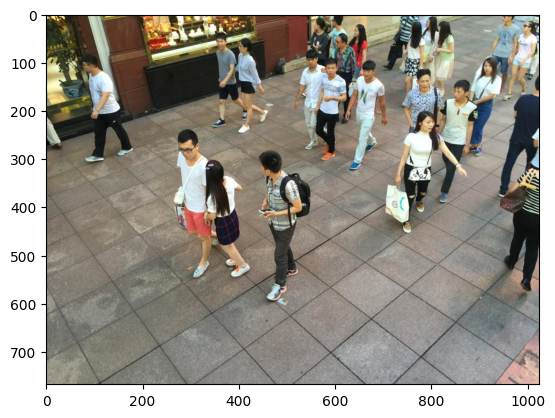

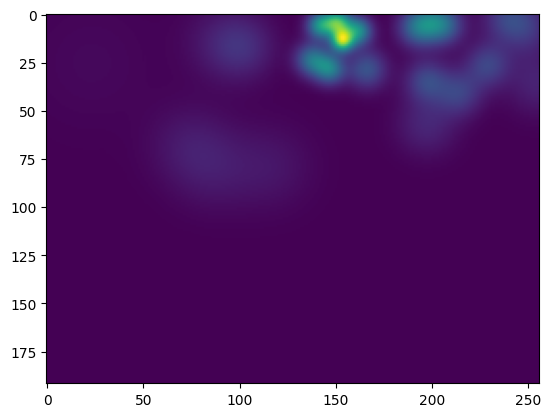

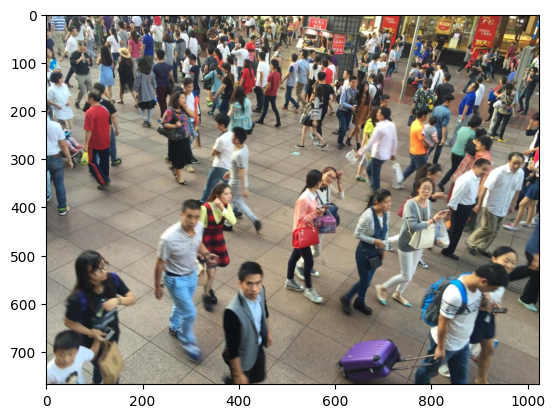

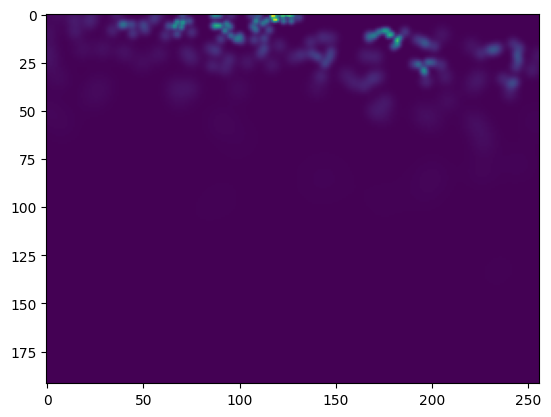

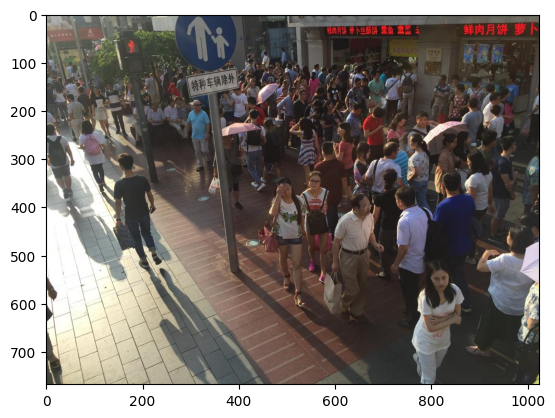

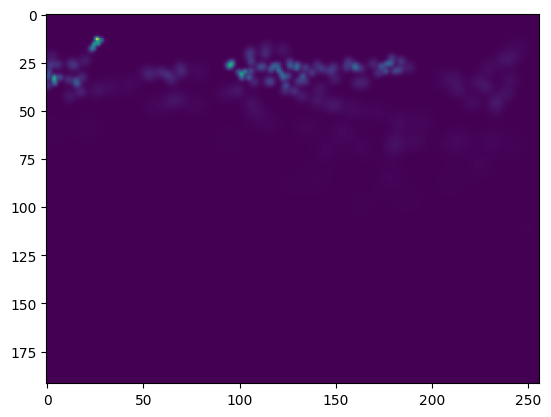

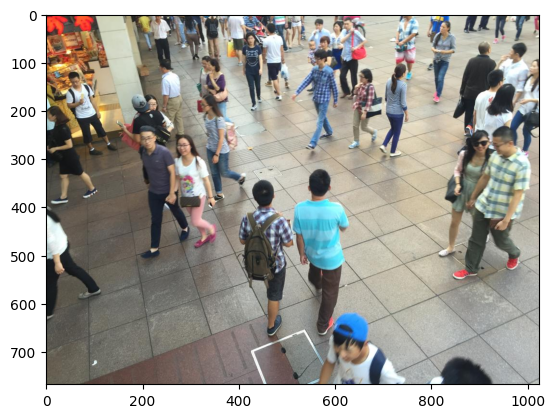

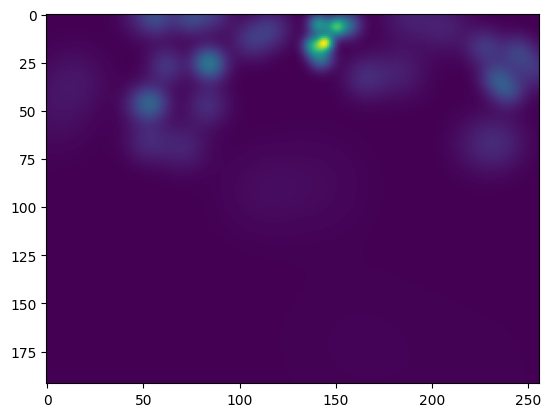

<Figure size 640x480 with 0 Axes>

In [ ]:
model.eval()
for i,(img,gt_dmap) in enumerate(train_dataset):
    pred = img.unsqueeze(0)
    pred = model(pred.to(device)).squeeze(0)
    plt.imshow(img.permute(1, 2, 0))
    plt.figure()
    plt.imshow(gt_dmap.permute(1, 2, 0))
    plt.figure()
    print(img.shape,gt_dmap.shape, pred.shape)
    plt.imshow(pred.permute(1, 2, 0).cpu().detach().numpy())
    plt.figure()
    if i>2:
        break
    
    print(gt_dmap.dtype)
    print(gt_dmap.sum())
    print(pred.sum())

In [ ]:
plt.plot(history['train_loss'])

float16


In [ ]:
model = MCNN()
model.load_state_dict(torch.load('/kaggle/working/MSC-thesis/output/models/mcnn/mcnn.pth'))
model.eval()
model = model.to(device)

In [ ]:
main_folders = [r"/kaggle/input/datasets/wiktorwoniak/shanghaitech-part-a/ShanghaiTech_part_A/test", 
                r"/kaggle/input/datasets/wiktorwoniak/shanghaitech-part-b/ShanghaiTech_part_B/test",
               r'/kaggle/input/datasets/wiktorwoniak/nwpu-crowd/NWPU-Crowd/val',
              r"/kaggle/input/datasets/wiktorwoniak/ucf-qnrf-eccv18/UCF-QNRF_ECCV18/test",
               r"/kaggle/input/datasets/wiktorwoniak/jhu-crowd-v2-0/jhu_crowd_v2.0/test",
               r"/kaggle/input/datasets/wiktorwoniak/ucf-cc-50/UCF_CC_50"]
evaluations = []
for folder in main_folders:    
    test_img_root = os.path.join(folder, "images")
    test_map_root = os.path.join(folder, "maps")
    test_dataset = CrowdDataset(test_img_root, test_map_root, gt_downsample=4, resize=False)
    test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False, pin_memory=True)
    mae, mse = evaluate_mae_mse(model, test_loader, device)
    rmse = mse**(1/2)
    evaluations.append({'dataset': folder.split('/')[-2] ,'mae': mae, 'rmse': rmse})

ShanghaiTech_part_A
2236.1318359375
62.95893478393555
427.0423644977611


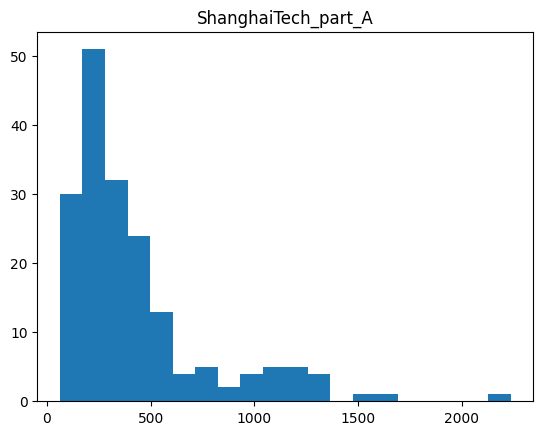

ShanghaiTech_part_B
536.7498168945312
8.17126750946045
118.9584851234774


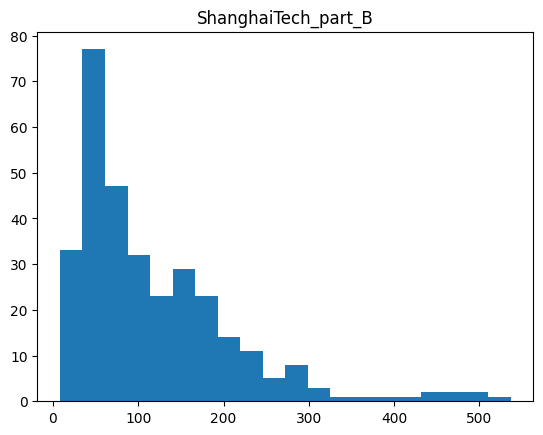

NWPU-Crowd
12917.658203125
0.0
389.4588443198204


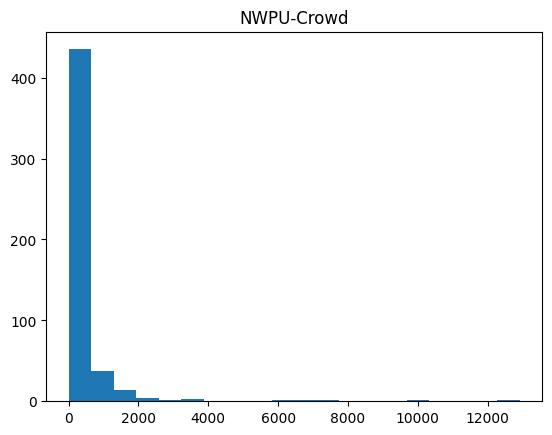

UCF-QNRF_ECCV18
4519.9931640625
63.94865036010742
712.7426579983648


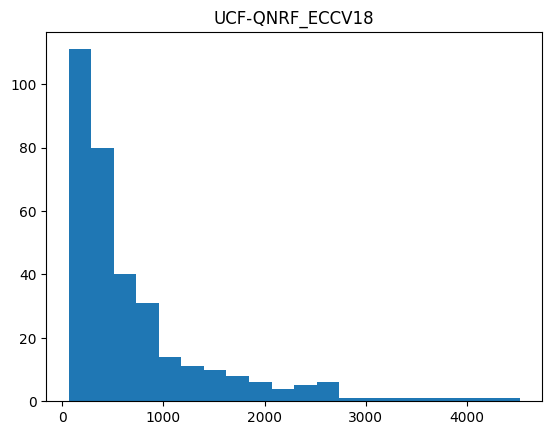

jhu_crowd_v2.0
9028.78515625
0.0
322.171075903438


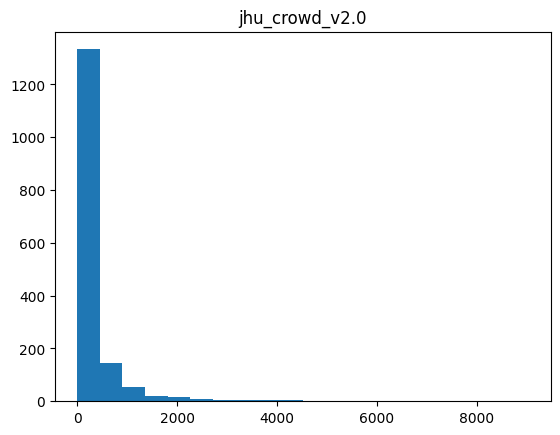

data
4613.3505859375
94.02760314941406
1272.609457092285


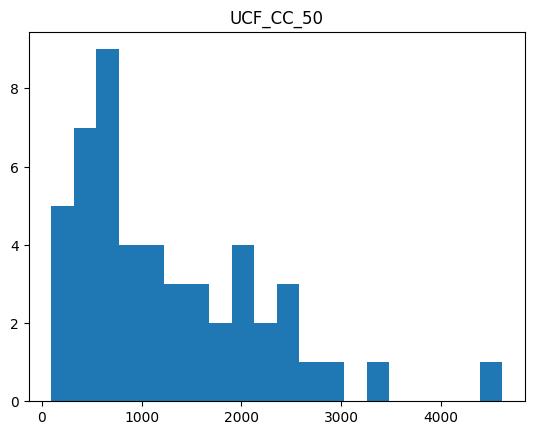

In [47]:
main_folders = [r"data\ShanghaiTech_part_A\test", 
                r"data\ShanghaiTech_part_B\test",
               r'data\NWPU-Crowd\val',
              r"data\UCF-QNRF_ECCV18\test",
               r"data\jhu_crowd_v2.0\test",
               r"data\UCF_CC_50"]

for folder in main_folders:
    evaluations = []    
    test_img_root = os.path.join(folder, "images")
    test_map_root = os.path.join(folder, "maps")
    test_dataset = CrowdDataset(test_img_root, test_map_root, gt_downsample=4, resize=False)
    for i,(img,gt_dmap) in enumerate(test_dataset):
        evaluations.append(gt_dmap.sum().item())
    print(folder.split('\\')[-2])
    print(max(evaluations))
    print(min(evaluations))
    print(np.mean(evaluations))
    if folder == r"data\UCF_CC_50":
        ind = -1
    else:
        ind = -2
    plt.hist(evaluations, bins=20)
    plt.title(folder.split('\\')[ind])
    plt.show()

In [ ]:
df = pd.DataFrame(evaluations)
df

In [ ]:
df.to_pickle(r'output\history\mcnn\evaluation')

In [3]:
df = pd.read_pickle(r'output\history\mcnn\evaluation')
df.to_csv(r'output\history\mcnn\evaluation.csv')

In [31]:
df = pd.read_csv(r'output\history\mcnn\evaluation_extended.csv')
df = df[df['gt'] != 0]
df.groupby('dataset').mean()

,Unnamed: 0,pred,gt,diff,abs_err,perc
dataset,,,,,,
NWPU-Crowd,743.675269,975.861345,418.772947,557.088399,882.345113,13.681922
ShanghaiTech_part_A,90.500000,446.087213,427.042364,19.044849,120.260550,0.402713
ShanghaiTech_part_B,339.500000,116.836240,118.958485,-2.122245,33.489226,0.392213
UCF-QNRF_ECCV18,1164.500000,1038.252162,712.742658,325.509504,781.925577,1.760821
jhu_crowd_v2.0,2131.270050,486.377375,322.978524,163.398851,308.313064,4.798321
ucf-cc-50,2956.500000,1243.442815,1272.609457,-29.166642,418.276023,0.371667


In [32]:
df.sort_values(by='diff', ascending=False)

,Unnamed: 0,dataset,pred,gt,diff,abs_err,perc
1254,1254,UCF-QNRF_ECCV18,45179.507812,1025.082397,44154.425415,44154.425415,43.074026
531,531,NWPU-Crowd,19733.046875,42.899265,19690.147610,19690.147610,458.985660
1338,1338,jhu_crowd_v2.0,19525.089844,735.696045,18789.393799,18789.393799,25.539615
1512,1512,jhu_crowd_v2.0,18928.898438,185.688065,18743.210373,18743.210373,100.939231
1320,1320,UCF-QNRF_ECCV18,19637.460938,1202.014404,18435.446533,18435.446533,15.337126
...,...,...,...,...,...,...,...
1804,1804,jhu_crowd_v2.0,336.120544,3636.726807,-3300.606262,3300.606262,0.907576
2826,2826,jhu_crowd_v2.0,1042.388306,4615.838867,-3573.450562,3573.450562,0.774171
697,697,NWPU-Crowd,5456.321777,9710.422852,-4254.101074,4254.101074,0.438096
1629,1629,jhu_crowd_v2.0,1344.000000,6196.994141,-4852.994141,4852.994141,0.783121


Text(0, 0.5, 'Difference')

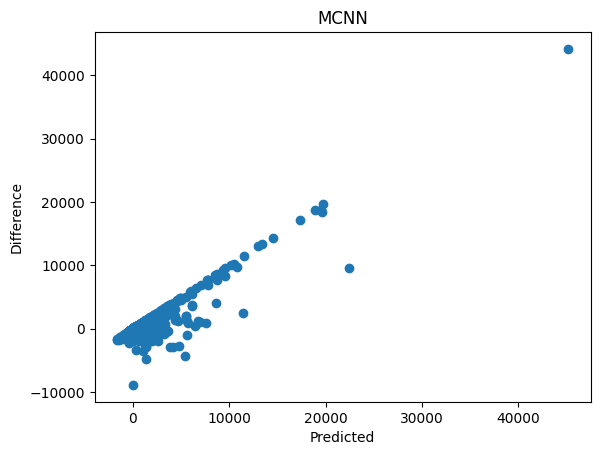

In [33]:
plt.scatter(df['pred'], df['diff'])
plt.title('MCNN')
plt.xlabel('Predicted')
plt.ylabel('Difference')

Text(0, 0.5, 'Predicted')

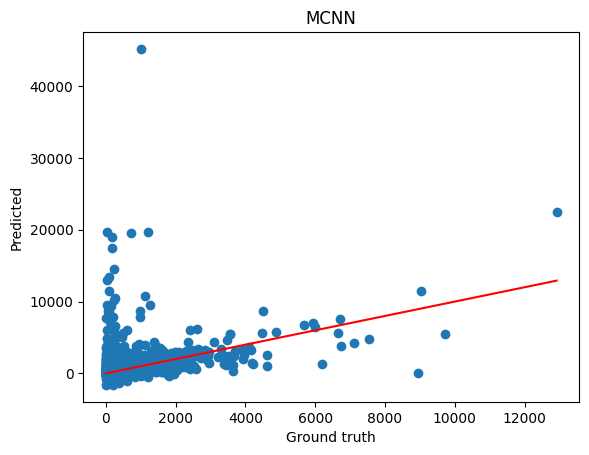

In [34]:
plt.scatter(df['gt'], df['pred'])
plt.plot([0,max(df['gt'])], [0, max(df['gt'])], color='red')
plt.title('MCNN')
plt.xlabel('Ground truth')
plt.ylabel('Predicted')

Text(0, 0.5, 'Error')

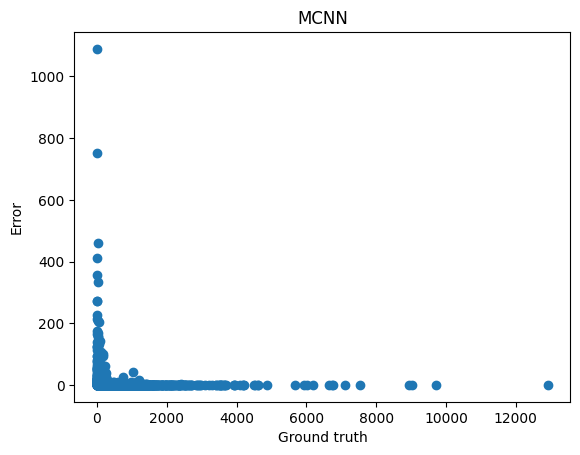

In [35]:
plt.scatter(df['gt'], df['perc'])
plt.title('MCNN')
plt.xlabel('Ground truth')
plt.ylabel('Error')

In [24]:
df = pd.read_csv(r'output\history\mcnn\evaluation_extended.csv')
df = df[df['gt'] != 0]
df['bins'] = df['gt'].apply(lambda x: bins(x))
df['rmse'] = (df['pred'] - df['gt'])**2
df.drop(columns='dataset', inplace=True)
df = df.groupby(['bins']).mean()
df['rmse'] = df['rmse']**(1/2)
df

,Unnamed: 0,pred,gt,diff,abs_err,perc,rmse
bins,,,,,,,
high,1375.040733,654.677423,434.090386,220.587036,420.194530,1.118677,1210.803014
large,1609.323077,2257.614944,2147.949189,109.665754,1195.570690,0.690665,3390.628560
medium,1459.517711,332.593279,114.584876,218.008403,284.273666,2.628882,1173.566271
small,1720.323333,268.386648,27.167932,241.218716,300.733954,17.752720,1243.441038


In [43]:
df = pd.read_csv(r'output\history\mcnn\evaluation_extended.csv')
df = df[df['gt'] == 0]


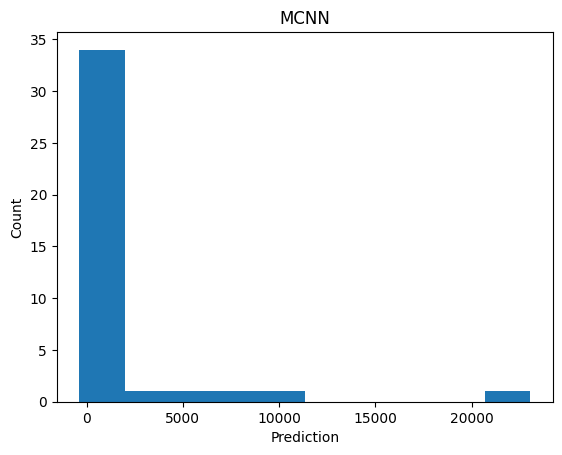

In [44]:
plt.hist(df['pred'])
plt.xlabel("Prediction")
plt.ylabel("Count")
plt.title('MCNN')
plt.show()

In [25]:
df2 = pd.read_csv(r'output\history\csrnet\evaluation_extended.csv')
df2 = df2[df2['gt'] != 0]
df2.groupby('dataset').mean()

,Unnamed: 0,pred,gt,diff,abs_err,perc
dataset,,,,,,
NWPU-Crowd,743.675269,320.380953,418.884670,-98.503717,184.430650,1.948088
ShanghaiTech_part_A,90.500000,357.907143,427.786075,-69.878932,93.279034,0.224682
ShanghaiTech_part_B,339.500000,98.411443,118.925277,-20.513834,29.987791,0.265893
UCF-QNRF_ECCV18,1164.500000,499.011891,713.123521,-214.111630,255.018786,0.338692
jhu_crowd_v2.0,2131.270050,259.402288,323.375047,-63.972760,115.670650,1.074153
ucf-cc-50,2956.500000,955.423863,1272.469122,-317.045259,397.088451,0.283933


Text(0, 0.5, 'Difference')

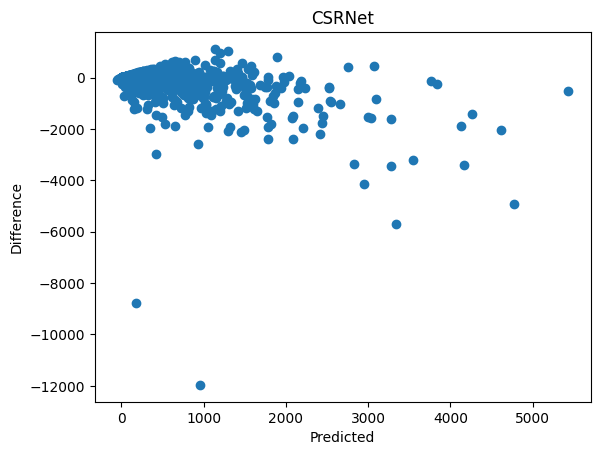

In [26]:
plt.scatter(df2['pred'], df2['diff'])
plt.title('CSRNet')
plt.xlabel('Predicted')
plt.ylabel('Difference')

Text(0, 0.5, 'Predicted')

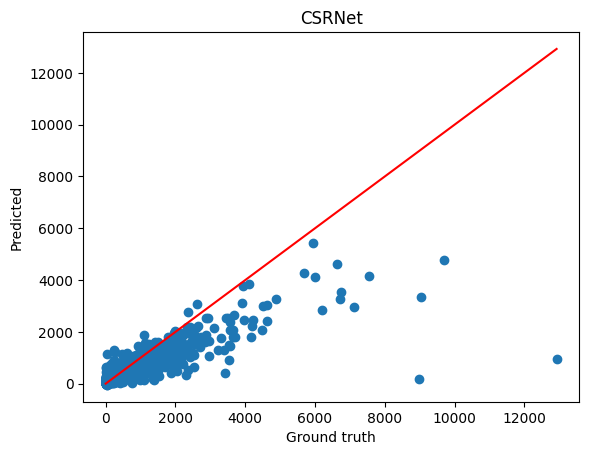

In [27]:
plt.scatter(df2['gt'], df2['pred'])
plt.plot([0,max(df2['gt'])], [0, max(df2['gt'])], color='red')
plt.title('CSRNet')
plt.xlabel('Ground truth')
plt.ylabel('Predicted')

Text(0, 0.5, 'Error')

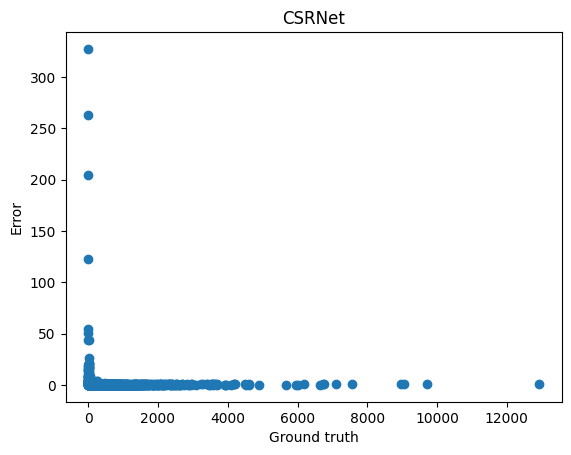

In [30]:
plt.scatter(df2['gt'], df2['perc'])
plt.title('CSRNet')
plt.xlabel('Ground truth')
plt.ylabel('Error')

In [22]:
def bins(x):
    if x <= 50:
        return 'small'
    if x <= 200:
        return 'medium'
    if x <= 1000:
        return 'high'
    else:
        return 'large'

In [23]:
df2 = pd.read_csv(r'output\history\csrnet\evaluation_extended.csv')
df2 = df2[df2['gt'] != 0]
df2['bins'] = df2['gt'].apply(lambda x: bins(x))
df2['rmse'] = (df2['pred'] - df2['gt'])**2
df2.drop(columns='dataset', inplace=True)
df2 = df2.groupby(['bins']).mean()
df2['rmse'] = df2['rmse']**(1/2)
df2

,Unnamed: 0,pred,gt,diff,abs_err,perc,rmse
bins,,,,,,,
high,1376.074262,356.462271,434.351986,-77.889715,123.825805,0.286325,174.820491
large,1609.323077,1364.434418,2148.975181,-784.540763,818.095470,0.327694,1429.962947
medium,1458.670909,120.294637,114.641917,5.652720,40.744784,0.378361,66.606348
small,1720.323333,60.303356,27.207425,33.095930,37.682303,3.482646,91.692187


In [39]:
df2 = pd.read_csv(r'output\history\csrnet\evaluation_extended.csv')
df2 = df2[df2['gt'] == 0]


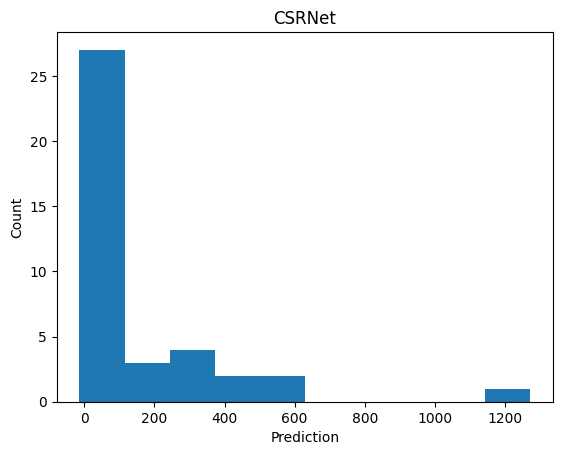

In [40]:
plt.hist(df2['pred'])
plt.xlabel("Prediction")
plt.ylabel("Count")
plt.title('CSRNet')
plt.show()